Randomised Riemannian Hamiltonian Monte Carlo for Bayesian Estimation as a Constrained Distribution Problem

Defined by $g(X,d_{1},d_{2}) = X^{T}X - \mathbb{I}_{p} = 0$, we have $\mathcal{M} := \{(X,d_1 , d_2 ) \in \mathbb{R}^{d \times p}\times \mathbb{R}^{p} \times \mathbb{R}^d \mid g(X) = 0\}$

For $A \in \mathbb{R}^{d \times p}$ with $v_{i} \in \mathbb{R}^{d}$, $i = 1,...,p$ being the column vectors. We define $g_{ij}(A) = v_{i} \cdot v_{j} - \delta_{ij} = 0$


1) Dynamics

In [1]:
import numba
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
import random

# Data Extraction

In [2]:
import os
from os import sys

In [3]:
data_matrix = np.zeros((120,2000))


for k in range(1,2001):
    file_location = './cov_shrink_simulations/'
    if k < 10:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
    
    if 10 <= k < 100:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2              =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
        
    if 100 <= k < 1000:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    if 1000 <= k:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    temp12  = np.append(temp1, temp2, axis = 0)
    temp123 = np.append(temp12,temp3, axis = 0)
    #print(np.shape(temp123))
    data_matrix[:,k-1]  = np.reshape(temp123,(len(temp123),))
        


In [4]:
# Astronomical Data
#n = 2000
N = 120
N = 60

p =  N//6
d =  N
m =  p

In [5]:
n = N*2//3
Data = data_matrix[:N,:2000]

mean = np.mean(Data[:,:n],axis = 1)
var = np.var(Data[:,:n],axis = 1)

    
    
for i in range(2000):
    Data[:,i] -= mean
    Data[:,i] /= np.sqrt(var)


In [6]:
# np.max(Data)

In [7]:
# np.min(Data)

In [8]:
# np.mean(Data,axis = 1)

In [9]:
mean = np.mean(Data[:,:n],axis = 1)

# Data_matrix_2 = np.zeros((N,n))

# for i in range(N):
#     Data_matrix_2[i,:] = Data_matrix_2[i,:] - mean[i]
    
# maximum = np.max(abs(Data_matrix_2))
# print(maximum)

We are sampling from the von Mises-Fisher distribution which has density given by 

$p_{vMF}(X) \propto \exp{(\langle f_{1},x_{1} \rangle + ... + \langle f_{p},x_{p}\rangle)}$

In [10]:

#print(np.mean(abs(np.random.normal(0,1,2000))))

# Preconditioning

[-3.57136196e-16  1.49186219e-16  1.80411242e-16 -3.40005801e-16
 -9.36750677e-17  2.77555756e-16  1.01047642e-16  1.80411242e-16
  3.31332184e-16  2.60208521e-16  1.50920942e-16 -6.59194921e-17
  0.00000000e+00 -6.93889390e-17 -4.16333634e-17  5.55111512e-17
 -1.04083409e-17  2.42861287e-17 -1.11022302e-16  4.16333634e-17
  1.38777878e-17  0.00000000e+00 -1.04083409e-17  2.01227923e-16
 -2.60208521e-18  6.93889390e-17 -6.59194921e-17  7.63278329e-17
  2.22044605e-16  3.57353036e-16  1.64798730e-17 -9.71445147e-17
  6.93889390e-17 -1.83880688e-16  1.30971622e-16 -4.05925293e-16
 -2.02312125e-16 -1.40512602e-16 -1.33573708e-16 -3.20923843e-17
  5.68989300e-16  1.63064007e-16  2.22044605e-16  1.17961196e-16
  2.15105711e-16  9.02056208e-17 -2.77555756e-16  1.38777878e-17
 -4.09394740e-16  9.71445147e-17  2.08166817e-17  4.07660017e-16
  1.94289029e-16 -4.16333634e-17  3.12250226e-17  4.16333634e-17
  3.12250226e-17 -1.99493200e-17  8.83624771e-18  4.85722573e-17]


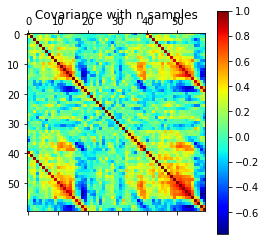

In [11]:
# sample variance
mean2 = np.zeros(d)
for i in range(n):
    mean2 += Data[:,i]/n
    
S_small = np.zeros((d,d))
for i in range(n):
    x = Data[:,i] - mean2
    S_small += np.outer(x,x)/n

print(mean2)

plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [12]:
D_2 = np.diag(np.diag(S_small))
Pmat = (S_small - D_2)


EIG = np.linalg.eig(Pmat)
A  = np.zeros((d,p))
for i in range(p):
    A[:,i] = EIG[1][:,i]



D_1 = np.diag(EIG[0][:p])

Approx = np.matmul(A,np.matmul(D_1,np.transpose(A)))
D_2 = np.diag(np.diag(S_small)) - np.diag(np.diag(Approx))
Approx += D_2

# Sampling

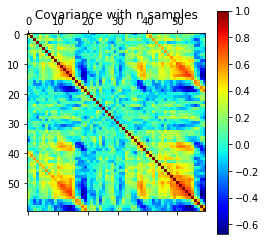

In [13]:
    
plt.matshow(Approx,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [14]:
#p<=d



p =  N//6
d =  N
m =  p


dimension = int(d*p+p+d)
num_of_constraints  = int(p*(p+1)/2)

σ_1 = 2
σ_2 = 2
#Matrix in distribution

@numba.jit(nopython=True)
def vec_to_matrix(q):
    X = np.zeros((d,p))
    for i in range(d):
        for j in range(p):
            X[i,j] = q[j*d+i]
    return X

@numba.jit(nopython=True)
def matrix_to_vec(X):
    #initialising filler array
    x = np.zeros(d*p)
    
    for i in range(d*p):
        i_index = i%d
        j_index =  int((i - i_index)/d)
        x[i] = X[i_index,j_index]
    return x

@numba.jit(nopython=True)
def dot_product(v1,v2):
    dot = 0
    for i in range(len(v1)):
        
        dot += v1[i]*v2[i]
        
    return dot

@numba.jit(nopython=True)
def matmul(matrix1,matrix2):
    a = matrix1.shape[0]
    b = matrix2.shape[1]
    c = matrix2.shape[0]
    rmatrix = np.zeros((a,b))
    for i in range(a):
        for j in range(b):
            for k in range(c):
                rmatrix[i,j] += matrix1[i,k] * matrix2[k,j]
    return rmatrix

@numba.jit(nopython=True)
def matrix_vec_multiplication(A,x):
    v = np.zeros(len(A))
    
    for i in range(len(A)):
        for j in range(len(x)):
                v[i] += A[i][j] * x[j]
    return v


@numba.jit(nopython=True)
def g_ij(q,i,j):
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    if i==j:
        y = np.linalg.norm(X[:,i])**2 - 1
    else:
        y = dot_product(X[:,i],X[:,j])
        
    return y


@numba.jit(nopython=True)
def G(q): #considering i<j.
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    z = np.zeros((dimension,num_of_constraints))
    
    for i in range(p): #block diagonals
        z[d*i:d*(i+1),int(p*i-0.5*i*(i-1)):int(p*(i+1) - 0.5*i*(i+1))] = X[:,i:]
    
        #vector diagonals
        for j in range(p-i):
            z[(j+i)*d:(j+i+1)*d,int(p*i-0.5*i*(i-1) + j)] += X[:,i]  
    z = z.T #could implement this above
    return z


In [15]:
@numba.jit(nopython=True)
def potential_derv_fast(q):
    #Can check with numerical differentiation.
    
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    
    Σ_inv_T = np.transpose(np.linalg.inv(Σ))

    #Constructing M
    M_kl = 0.5*n*Σ_inv_T 
    
    for k in range(d):
        for l in range(d):
            for r in range(n):
                M_kl[k,l] -= 0.5*dot_product(Data[:,r]-mean,Σ_inv_T[k,:])*dot_product(Σ_inv_T[:,l],Data[:,r]-mean)
    
    #dUdX
    dUdX = np.zeros((d,p))
    
    for i in range(d):
        
        for j in range(p):
            
            for k in range(d):
                
                for l in range(d):
                    
                    if k == i and l == i:
                        
                        dΣ_kl_dX_ij = 2*X[i,j]*d_1[j]
                        
                    elif k == i:
                        
                        dΣ_kl_dX_ij = d_1[j]*X[l,j]
                        
                    elif l == i:
                        
                        dΣ_kl_dX_ij = X[k,j]*d_1[j]
                    
                    else:
                        continue
                    
                    dUdX[i,j] += M_kl[k,l]*dΣ_kl_dX_ij
                    
                
            
    
    #dUd1
    dUd1 = np.zeros(p)
    
    for j in range(p):
    
        for k in range(d):
                
            for l in range(d): 
                    
                dΣ_kl_dD1_jj = X[k,j]*X[l,j]

                dUd1[j] += M_kl[k,l]*dΣ_kl_dD1_jj

        #adding extra term
        dUd1[j] += d_1[j]/(σ_1)**2
    
   
    #dUd2
    dUd2 = np.zeros(d)
    
    for j in range(d):

        dUd2[j] += M_kl[j,j]*1.
        
        #adding extra term
        dUd2[j] += d_2[j]/(σ_2)**2
    
    pot_derv = np.zeros(int(d*p+p+d))
    pot_derv[:d*p] = matrix_to_vec(dUdX)
    pot_derv[d*p:d*p+p] = dUd1
    pot_derv[d*p+p:] = dUd2
    
    return pot_derv

In [16]:
q_initial = list(matrix_to_vec(np.eye(d,p)))
d_1 = abs(np.random.normal(0,σ_1,p))
d_2 = abs(np.random.normal(0,σ_2,d))
q_initial += list(d_1)
q_initial += list(d_2)
q_initial = np.array(q_initial)
x_init = q_initial
#x_init = q_initial
print(x_init)

[1.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         1.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [17]:
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  4.1938605308532715
time after compiling =  0.14298295974731445


In [18]:
#RATTLE Hamiltonian Flow
@numba.jit(nopython=True)
def RATTLE_with_Potential(x0,v0,t,dt,max_elim_iters):
    n = np.floor(t/dt)
    vn = v0
    qn = x0
    vhalf = v0
    G_q = G(qn)
    
    #Gram Matrix is GG^T
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    
    
    pderv = potential_derv_fast(qn)#potential_derv(qn)
    
    residual_list = np.zeros(num_of_constraints)
    for i in range(int(n)):
        
        
        #solver for Lagrange position multipliers
        Q = qn + vn*dt - 0.5*dt*dt*pderv
        
        #non-linear gaussian elimination
        for k in range(max_elim_iters): #i>j
            for i in range(p):
                for j in range(i,p):
                    g_Q = g_ij(Q,i,j)
                    index = int(i*p - 0.5*i*(i-1) + j-i)
                    
                    residual_list[index] = g_Q
                    if abs(g_Q) < 1e-8:
                        continue
                    G_Q = G(Q)
                    
                    #should be sum of i's and js in indexing below
                    dlambda = g_Q/dot_product(G_Q[index,:],G_q[index,:])
                    Q = Q - G_q[index,:]*dlambda
            #break condition
            if np.all(np.abs(residual_list)<1e-8):
                break

        
        #half step
        vhalf = (Q-qn)/dt
        qn = Q
        
        pderv = potential_derv_fast(qn) #potential_derv(qn)
        G_q = G(qn)
        
        gram = matmul(G_q,G_q.T)
        gram_inv = np.linalg.inv(gram)
        
        #linear solver Lagrange velocity multipliers
        b = matrix_vec_multiplication(G_q,2*vhalf/dt - pderv)
        coeffs_v = matrix_vec_multiplication(gram_inv,b)
        
        #full step
        vn = vhalf - 0.5*dt*pderv - 0.5*dt*matrix_vec_multiplication(G_q.T,coeffs_v)
       
    return qn,vn

# Checks

In [19]:
X = np.array([[1,2,3], [4,5,6],[7,8,9]])
#print(X[:,1:])
#g_ij checked
#G checked for what I want.
#print(X.T,X)
M = np.eye(d, p)
M = matrix_to_vec(M)
gram = matmul(G(M),G(M).T)
"G matrix should be #constraints by dimension 0.5*p*(p+1) by p*d" 
#6 by 9
print(gram)
M = np.eye(d, p)


[[4. 0. 0. ... 0. 0. 0.]
 [0. 2. 0. ... 0. 0. 0.]
 [0. 0. 2. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 4. 0. 0.]
 [0. 0. 0. ... 0. 2. 0.]
 [0. 0. 0. ... 0. 0. 4.]]


2) Event Time Sampling


In [20]:
#Sampling Event Times
@numba.jit(nopython=True)
def time_exp(lam):
    t = np.random.exponential(lam)
    return t

3) Gaussian Sampling on Tangent Space

In [21]:
@numba.jit(nopython=True)
def tangent_space_gaussian(q):
    
    
    v = np.random.normal(0.,1.0,dimension).T
    
    
    G_q = G(q)
    
    
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    proj_matrix = np.eye(dimension) - matmul(G_q.T,matmul(gram_inv,G_q))
    
    #sample 3d gaussian and then project onto tangent space.
    v = matrix_vec_multiplication(proj_matrix,v)
    
    return v

#check
Z = tangent_space_gaussian(x_init)
T_X = vec_to_matrix(Z[:d*p])  
X = vec_to_matrix(x_init[:d*p])
print('constraint check =',matmul(T_X.T,X) + matmul(X.T,T_X))
print('Should be Gaussian no constraints =',Z[d*p:])

constraint check = [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Should be Gaussian no constraints = [-0.29252486  0.75527008 -1.12817091  1.09497794  0.27133051  0.22585465
 -0.92566865 -0.17702878  1.31579617  0.54063984 -0.07337161  0.89587151
  0.43002033 -0.65019749  0.10455913  0.99935167 -1.33846305 -0.88042737
  1.17816035  0.16002925 -1.59063455  1.53998781  0.36145644 -1.18678883
 -0.29916427 -0.4171561  -0.74095235 -1.13759493 -0.21004306 -0.29830204
 -0.87102555  0.0255222   0.47547167 -0.55046723  0.30572256 -0.63707288
  0.21578083 -1.02875161  0.17008534 -0.31586443  0.02633029 -2.73154856
  0.16454044  0.29388379  0.6545266  -1.25712263  0.27017823 -0.82999777
 -0.1056032   0.71981053  0.19

In [22]:
t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  5.576862573623657
time after compiling =  1.6600489616394043


In [23]:
@numba.jit(nopython=True)
def U(q):
    
    X = vec_to_matrix(q[:d*p])
    
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    Σ_inv = np.linalg.inv(Σ)
    
    #likelihood
    pot = 0.5*n*np.log(np.linalg.det(Σ)) + 0.5*n*p*np.log((2*np.pi))
    for i in range(n):
        Bx = matrix_vec_multiplication(Σ_inv,Data[:,i]-mean)
        pot += 0.5*dot_product(Data[:,i]-mean,Bx)
        
    #prior
    #don't need uniform prior because it's constant
    pot += 0.5*np.log(2*np.pi*(σ_1)**2)
    pot += 0.5*dot_product(d_1,d_1)/(σ_1)**2
    
    pot += 0.5*np.log(2*np.pi*(σ_2)**2)
    pot += 0.5*dot_product(d_2,d_2)/(σ_2)**2
    
    return pot


# @numba.jit(nopython=True)
# def f(q):
    
#     z = U(q)
    
#     return z

@numba.jit(nopython=True)
def hamiltonian(x,v):
    return U(x) + 0.5*dot_product(v,v)

In [24]:
def Potential_approx_deriv(q,ϵ):
    δV = np.zeros(len(q))
    for i in range(len(q)):
        h = np.zeros(len(q))
        h[i] = ϵ
        δV[i] = (U(q+h)-U(q-h))/(2*ϵ)
    return δV

In [25]:
@numba.jit(nopython=True)
def f(q):
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    return Σ

In [26]:
#Testing 
q_initial = list(matrix_to_vec(A))

d_1 = np.diag(D_1) #abs(np.random.normal(0,σ_1,p))
d_2 = np.diag(D_2) #abs(np.random.normal(0,σ_2,d))

q_initial += list(d_1)
q_initial += list(d_2)
q_initial = np.array(q_initial)
x_init = q_initial
x_init = [-0.008749197951231087, 0.033159446984533894, 0.12282922357826749, -0.012914858228069082, 0.010224627054717453, 0.08277041136850703, 0.1672390438237998, 0.20096053100821593, 0.13612111785865164, 0.14045626140486486, 0.23674178997256773, 0.2813800788346782, 0.15375577302940652, 0.15455614528924597, 0.15168205665821538, 0.06710779990881698, -0.1355496082450888, -0.11180390306805123, -0.07959154019309012, -0.05296234609666518, 0.11007098613699483, -0.016699044514943893, -0.0005030855976759658, 0.008053836046802324, -0.007696275183627738, -0.1143003018790683, 0.02311583586665626, 0.022175159380178496, 0.05678054293953695, -0.025168719193883877, 0.0055672284669929075, -0.038975128213488607, -0.17898970207838327, 0.010064489236393883, 0.034661837326044456, 0.0929660112160394, 0.09108728554344195, 0.19115474161110213, 0.18451589584094952, 0.1746734746123062, 0.02728351417758141, 0.049374884008585515, 0.14092023622603853, 0.027185867480816406, 0.16221197548094404, 0.14294507319969665, 0.09147888532384846, 0.15782551864086083, 0.16212649284419042, 0.16616580609253984, 0.21562086511053874, 0.27650366465807, 0.21158989606450807, 0.1838915431967853, 0.19436906913075144, 0.04392822435900512, -0.13717310701041893, -0.05137842080120883, -0.1002287930227523, -0.07676103264473831, -0.032412347543833334, 0.002761631498003315, 0.1810024568678496, 0.1396944161796223, -0.034386454741912306, -0.0055764537749481615, 0.050074458534406646, 0.13351542716020726, 0.08957927481034925, -0.03424868625256443, 0.008602387357886467, 0.0796563774364718, -0.10179180593922181, -0.204417810611329, -0.21643350180716306, -0.17235502971808248, -0.2545776981325972, -0.1139776739671215, 0.14080878828490265, 0.15692065228718635, 0.07313574531106397, 0.08527684690549918, 0.14833315741870204, 0.004475348514602747, 0.09879953340808718, -0.22641236202033005, 0.09613569660660229, -0.06618079008845879, 0.02068423532596935, -0.06518402627307396, -0.013940857761811183, -0.00032097353259628766, -0.11548693284306258, 0.02399504140000716, -0.0929358324837705, 0.23069003914874056, 0.142544545171458, 0.15141821535272976, -0.028859568449562636, -0.15671769438439576, -0.11975630327815466, -0.042181283011826075, 0.09926469078808513, 0.07946611697187682, 0.04953846026006812, 0.030299609024177426, -0.009869347237602192, 0.006131685445540761, 0.024986850748451975, -0.047670432088974785, -0.03637785446419754, 0.0231540468251473, -0.1554389148278436, -0.20419497267221803, -0.2186169996701308, -0.2906847415361308, -0.25358873763920614, -0.07830552701744439, 0.2133354568935651, 0.21291230119255772, 0.030446359540972925, 0.20846618479968643, 0.13343693256580716, 0.4709799748314258, -0.02222238608372981, 0.09769834175206066, 0.0808828276248342, -0.05917821824422748, -0.04175708128639638, 0.04439730486883343, 0.061247469335413085, -0.06288426620722797, -0.11325520698740818, -0.022333601344611202, -0.006857703209710406, 0.039267021328195637, 0.11481745057367292, -0.21665814157314428, -0.22791981191055716, -0.06818978941981098, 0.010449009029518654, -0.09373781905591763, -0.09356176965640206, -0.06267288724895025, -0.053900631117661246, 0.08117320449896422, -0.05462858677796235, -0.03022099191757656, -0.05120661011335956, -0.021541277658188057, 0.073189565445737, 0.04570675265471226, 0.05044557817849367, 0.01960268866810452, 0.07360396493989883, 0.14176835745172436, -0.1741465747209186, -0.10197708158530693, -0.05289860064506319, 0.05770615577365543, 0.0349778508602854, 0.1849509168444439, 0.1258422040705892, 0.5066729917467941, 0.05235002630995129, 0.054456698954144386, 0.06509760858446575, -0.04018033209332802, -0.04512789279969773, -0.14352606591082376, 0.014840811911568446, -0.056447369619472366, -0.1729014302643862, -0.010234077450805144, 0.08268501014869052, 0.0742594809435528, 0.026892785896687574, -0.20512638307055228, -0.012228024390004326, -0.03408505578567236, -0.10077332535857622, -0.06392427162752591, 0.21840800687871037, 0.0322737367774518, 0.01897071615470561, 0.025344153725060794, -0.06782686166435822, -0.08344597792040265, -0.41289494154509643, -0.006884400084314914, 0.028756275140707728, 0.10602035894631762, -0.0688767493952916, 0.003372770326690402, 0.1253731021644822, -0.02463955582985417, 0.0838221454829103, 0.04160607824283274, -0.04756552131870788, -0.20331836220603103, -0.16887018542507198, -0.23799764528729064, 0.021878144251198592, -0.14115108902219403, -0.07823553950773979, -0.2110823137364209, -0.08776272980654659, -0.09120423851115425, -0.11175374633857384, -0.0871866632578102, -0.018443885682038152, -0.00025667957091232187, -0.14357593363533594, -0.14394000862679174, -0.15166380444217356, 0.023724622902167408, 0.1684435012847818, -0.03158545257317687, -0.011461742863416623, 0.1508202071407878, -0.11971692167278909, -0.11636896165148992, 0.1698588679985917, -0.005024356029155926, -0.10137756989260917, -0.07670421277943168, -0.03926226671064478, -0.03931651072688718, -0.42332998283952045, -0.00857809648925043, -0.025093426933917265, 0.05866800705136057, 0.22060957502058554, -0.06579921979801888, -0.04227451258420841, -0.12475866676287141, -0.10393967277083321, 0.08005226747843434, -0.025095054796387354, -0.10503356821950775, -0.12286238291455644, 0.15168276658135513, -0.36461653054232435, 0.032425046471376666, 0.06057847809041382, -0.049784856853626734, -0.00713404151040927, 0.12399029751738996, -0.1032477693456881, -0.07541004341548563, 0.24457208819895637, -0.04340453685502672, 0.10060001706841995, -0.026915651991010925, -0.07614882995410002, 0.008377508455533797, -0.044494178186300096, 0.059993228632755836, -0.1714987477553519, 0.11260729059649313, 0.05440814925710749, 0.15021938283903283, -0.003286149519346073, 0.016218158301193195, 0.05983359902552076, -0.1775523957507058, -0.3186986229862, -0.14092817713350822, -0.06795518035516095, 0.037945383297116574, -0.012711668123447947, -0.05905405226225182, -0.09757018985439286, -0.12105343420770216, 0.05409190304264585, -0.012979543926661365, -0.11509350720349297, 0.18666785726601762, 0.10180759892555871, 0.2624605118727609, 0.007100690692818679, 0.130602479404788, -0.344066712756313, 0.025745252310715595, -0.1735398922740892, 0.06182100766946026, 0.022700063212305742, -0.0643502480360763, -0.20429351936064027, -0.0805041909773928, 0.13820502318256822, -0.0286004883890588, -0.030154842577346984, -0.046074859196160195, -0.07997221870131563, 0.09056902456104819, -0.12599753694458302, 0.04433912891463046, 0.0830023195392315, 0.17889300722271773, -0.03710651566552791, -0.42238144434729225, 0.004664020679733184, 0.23028121567616552, -0.13133199069013884, 0.10352026634330762, -0.0050575393892214665, -0.08234666484647447, 0.16916579004615012, 0.11852399010974936, 0.08158958090489646, 0.2084068208753713, 0.021199032368395654, -0.10459119921035756, 0.0028837274202212918, -0.0679778893354152, 0.11270087823550282, -0.06406460245823149, -0.07922384116130564, 0.009921147657557743, 0.07306839136535562, 0.13116591165238176, 0.11155058407563868, -0.10495338919288641, 0.02409144847356841, -0.07121446665993258, -0.019793551139629974, 0.0050384020807657075, 0.1011331071900272, 0.0631320370653826, -0.1973893163267734, -0.15997277495927958, 0.16850981416663247, -0.06656116507992389, 0.03861612911229038, -0.06254770969627457, 0.05143942621992711, 0.0823971399955387, -0.024819019979961478, 0.15498084219053201, -0.0053493616560907585, -0.4627569842446745, -0.11851303792603435, 0.1267451934996776, -0.24012453611552956, 0.023109697296029682, -0.06725335136688733, -0.10271310253381855, 0.05268683998152496, -0.012527646433659815, 0.008759254772843955, 0.06777850305001024, -0.03610170077822989, -0.09321677977457152, 0.025268431596399868, 0.08751005084444985, 0.21172434506380175, -0.07664754924798259, -0.033343981434608996, -0.045240452085032, -0.21073299542946866, -0.163604450691856, -0.18407146248874887, 0.04406475812309892, 0.013561905192371977, -0.05245616056236529, 0.08579483341404702, -0.0749290870984422, 0.13541214080389347, 0.12089247461437243, -0.2544331443893813, -0.021608969578303126, 0.12507193293100174, 0.3282271972037555, -0.09878735213714576, 0.215494218183884, -0.0034108065793085167, -0.004236550599157401, -0.05057813314668988, -0.12543144018737956, -0.3300017985906799, 0.041282328273149344, 0.002057503112986159, 0.04511888911838565, -0.01109706680704836, -0.06421789320550751, -0.003257396953445525, -0.2026441006141379, 0.25604736202254974, -0.23249985581549254, -0.06173920076453666, 0.08903679500628076, -0.025508514657527785, -0.002755963124515547, -0.15632168556777, 0.09380752900220737, 0.03680392613436088, -0.08292650444139477, 0.2422617937612806, 0.030555034572627014, -0.016313673319772955, -0.0707060322747434, -0.03869673734057138, 0.16919600285231162, 0.13773794005266507, -0.013028410468927411, 0.011551865923161833, 0.010306833164489616, 0.04042220595941124, -0.03868542723408288, -0.0839129967702884, -0.08391083937623554, -0.04476641451244361, 0.11843883099969496, -0.19114617131348344, 0.05849447326971314, -0.11831356908200559, 0.009419368786599675, 0.21257331245818464, -0.05215177071753449, 0.07314041766334548, 0.03702525739663803, -0.14929806394645304, -0.010121200329080897, 0.1015053831296557, 0.07799779714744305, -0.06718251314724982, 0.03421883734240519, -0.15744506090298238, -0.02639236988885128, 0.09758436287698447, 0.12504479331455653, 0.06142431342001212, -0.14595137361275778, -0.13121883133399298, 0.1377711607450107, 0.30597624926547357, 0.03907514221559131, 0.11753288635979549, -0.1652721073856595, -0.05894422754860335, 0.04536310150290027, 0.10357894814469809, 0.0630767064363341, -0.025944863630632854, 0.033762727963995036, 0.01830990034076517, -0.011283430629197311, 0.09180312718614417, 0.28434584967335486, -0.11543081166026066, -0.09383816708819323, -0.05899512435002331, 0.1767830681888965, -0.04778036896316551, 0.17547053522921963, 0.19744827047832794, -0.08065017607562881, -0.06704764365217745, -0.2268138172285417, -0.005996531447307109, 0.1450773142466873, -0.03817660770560822, 0.1494426872213047, -0.03000435139775409, 0.20263266359619642, 0.02808032408720899, 0.22427300942881728, 0.006453171864859751, 0.06670239477275729, 0.16902463993634226, 0.16457169553104284, 0.052570242815805156, -0.13789449480014185, -0.12302441843389786, 0.0959295520686596, 0.1594492611278486, 0.13098839032319812, 0.28812312660695977, -0.16637618486748307, -0.05700022860372862, -0.2979308485103046, -0.00322796279494551, -0.10337588466293551, -0.07500502907377214, -0.2137911857830429, 0.017709427091404537, 0.09352309535269065, -0.03689003111226831, -0.0360289881877323, -0.0776304758452585, -0.24795786821815688, -0.0786796622329144, -0.23348897995851553, 0.0013564130992083678, 0.08272007110089229, -0.11615161343267252, -0.12255250128007045, -0.04556996126547269, -0.0012411364868165039, -0.10824180809997494, -0.12449248816286484, -0.19775627485757397, -0.1308232498380739, -0.004937347280591279, 0.00753297210528987, -0.0379087102771096, -0.05667252208424946, -0.039185284928184176, 0.2108372637532422, 0.029011916016238287, -0.059750725467902444, -0.19695701249525588, 0.20901725727288967, -0.02625494253502898, -0.007010660691960546, -0.22155244033398278, 0.034106886524825256, 0.0965387647210405, -0.07093296649435103, 0.2357205167933124, -0.15287851347679343, 0.15652571062931697, 0.06483651770898775, -0.14466219069040062, -0.10353533472777704, 0.1849047967430105, 0.10393278154967911, -0.00013980339937974526, 0.24633039485532235, 0.1823497604578782, -0.05914040275342428, 0.03163754024766232, -0.1081156394026455, 0.01808639688595372, 0.19228574388364258, -0.17752974999278903, -0.12419731130739702, 0.05562731688006876, 0.021699006390291313, -0.10203852011591202, -0.030295532583914972, 0.2912749030360623, -0.24742155688799, 0.04966044191196902, 0.2050606396818376, -0.03204553559054955, 0.11806574744403983, 0.08294836306892739, 0.14888480665893603, 0.21675655914598307, -0.22007885315249748, -0.1144171260904692, 0.018786829742452816, -0.10356922353713419, 0.17864195326922136, 0.222250403890167, 0.03537203933708904, 0.0442004240916948, 0.009548392449351378, -0.0862687047699431, 0.041358229055753946, 0.030758822548867467, 0.03686635320153858, 0.0179851282271938, -0.021296593742491272, -0.009592022478025819, -0.12239206613651792, 0.018555037264014425, 0.06030082527047213, -0.15629631213726278, 0.010614192381780263, 0.10258441164322178, -0.10378413193560723, 0.2861342414385382, -0.01362675556139752, -0.023462751950256017, -0.05157802058212188, 0.05138952118186907, 0.23887000499167546, -0.08722055307933362, -0.001488020918136127, 0.30399742751057257, -0.17814498514825117, 0.05717807869169874, 0.13594950954414298, -0.09396286199694823, 0.12232831505791068, -0.02738208656833028, -0.060440103022550956, 0.09774402498416081, -0.20749845137429704, -0.149634402188954, -0.03896963088288379, -0.14421442243409727, 0.09380356489465691, 0.02089395654733292, -0.0810772609466909, 0.05365851973282333, 0.17344933479887836, 11.876463159431644, 5.390396801791818, 3.119224790447387, 1.5822123184066874, 1.3736170928140319, 1.8900646787019943, 1.0320025442868104, 1.660841834050897, 1.632157008671489, 1.7318811250302353, 1.0388596871115594, 0.010196333747144057, 0.0009171648462527787, 0.0032851173417870615, 0.841069173769137, 0.9161642385820451, 0.9395139396916367, 0.6215921359637834, 0.12564096329290275, 1.0290506304752487, 0.12002247504673093, 0.04297341442889749, 0.3804170186086325, 0.049537449605341295, 0.19590976727294973, 0.7012987618987583, 0.08105794210655383, 0.9175111132312731, 0.3910896873247907, 0.4404114251243907, 0.9746944654099119, 0.9845560414116136, 0.810670700952345, 0.5434404064417976, 0.9080940002299799, 1.0870707197821345, 0.5722304114745185, 0.8286822806776082, 1.056098206397914, 0.7830771831393712, 1.464182147172363, 1.0017482363075236, 1.2361267822739512, 0.5158148607069776, 0.9078787843553826, 0.6838613893150541, 0.5949305228904587, 0.5032513470064853, 0.3920318792329727, 0.36432371160203986, 0.501901791877589, 0.004589757298985852, 0.00871171119154881, 0.0019529028714585128, 0.6169852247611156, 0.46973594515141703, 0.8035373495733245, 0.513103198514763, 0.014081256104418292, 0.33930048126645984, 0.06743012793043873, 0.020923726796590297, 0.37932973529471425, 0.02583585486138824, 0.027638873034237905, 0.44290983255173116, 0.11360191375481289, 0.7058759538423722, 0.5226697524091244, 0.31445214226957163]

x_init = np.array(x_init)

695.2640298165237


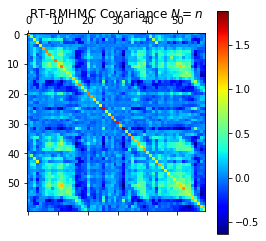

In [27]:
print(U(x_init))
plt.matshow(f(x_init),cmap='jet')
plt.colorbar()
plt.title('RT-RMHMC Covariance $N=n$')
plt.show()
#4 before

In [28]:
print(U(x_init))
t1 = time.time()
p1 = potential_derv_fast(x_init)
t2 = time.time()
p2 = Potential_approx_deriv(x_init,0.000000001)
t3 = time.time()
print('sup|grad_exact - grad_num| =',max(p2-p1))
print('Exact time = ',t2-t1)
print('Numerical time = ',t3-t2)

695.2640298165237
sup|grad_exact - grad_num| = 0.0019530777972036617
Exact time =  0.1148076057434082
Numerical time =  2.1885640621185303


4) Simulation

In [29]:
#Initialise
T = 0.01
num_of_events = 3
dt = 0.001

In [30]:
@numba.jit(nopython=True)
def RRHMC(num_of_events,dt_max,T,x_init):
    
    #Exponential Expected Value
    rate = T
    x = x_init
    
    position_list = [x_init]
    v = tangent_space_gaussian(x)
    
    accept = 0.
    gradient_evaluations = 0
    
    for i in range(num_of_events):
        
        t = time_exp(rate)
        L = np.ceil(t/dt_max)
        
        dt = t/L
        
        h = hamiltonian(x,v)
    
        xnew,vnew = RATTLE_with_Potential(x,v,t,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #adding in rejection for non-positive diagonal matrices.
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
            

        
        position_list.append(x)
        
        v = tangent_space_gaussian(x)
        if i%10==0:
            print(i)
        
        
    return position_list

In [31]:
@numba.jit(nopython=True)
def RHMC(num_of_events,dt,T,x_init):
    
#     x = list(matrix_to_vec(np.eye(d,p)))
#     x += list(np.ones(d + p))
    x = x_init
    #initialisation of x on V_{d,p} \times \mathbb{R}^p 
    #                        \times \mathbb{R}^d
    v = tangent_space_gaussian(x)
    
    position_list = [x]
    
    
    for i in range(num_of_events):
        
        h = hamiltonian(x,v)
        
        xnew,vnew = RATTLE_with_Potential(x,v,T,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #with reject with positivity constraint
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
        
        position_list.append(x)
        v = tangent_space_gaussian(x)  
        if i%10==0:
            print(i)
            
    return position_list

In [32]:
t = time.time()
position = RRHMC(num_of_events,dt,T,x_init)
elapsed = time.time() - t
print('RT time =',elapsed)
t = time.time()
position = RHMC(num_of_events,dt,T,x_init)
elapsed = time.time() - t
print('DT time =',elapsed)

0
RT time = 14.27542519569397
0
DT time = 8.696868181228638


# Check

In [33]:
#Initialise
#T = 0.1
num_of_events = 100000
dt = 0.001
N = 10
T = N*dt
#ensure positivity
#log normal prior

In [ ]:
position = RRHMC(num_of_events,dt,T,x_init)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180


In [ ]:
first_entry_list = []
first = 0
burn = 0
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    q = U(position[i+burn])
    first += q
    first_entry_list.append(first/(i+1))

In [ ]:
plt.plot(first_entry_list)
plt.title('U')
plt.xlabel('number of samples')

In [ ]:
#trace plots

In [ ]:
last_entry_list = []
last = 0
burn = 0
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    
    last += mat[0,-1]
    last_entry_list.append(last/(i+1))

In [ ]:
plt.plot(last_entry_list)
plt.title('A random entry')
plt.xlabel('number of samples')

In [ ]:
burn = 0
Σ_ave = np.zeros((d,d))
for i in range(num_of_events-burn):
    Σ_ave += f(position[i+burn])/(num_of_events-burn)
    #print(len(position[i+burn]))

In [ ]:
S = Σ_ave
print(S)

In [ ]:
plt.matshow(S,cmap='jet')
plt.colorbar()
plt.title('RT-RMHMC Covariance $N = 25$')
plt.show()
#4 before
#plot increase in maximum element

In [ ]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(S[i,j]))

In [ ]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
S_inv = np.linalg.inv(S)

In [ ]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

In [ ]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# True Covariance Matrix

In [ ]:
mean1 = np.zeros(d)
for i in range(2000):
    mean1 += Data[:,i]/2000

In [ ]:
S = np.zeros((d,d))
for i in range(2000):
    x = Data[:,i] - mean1
    S += np.outer(x,x)/2000

In [ ]:
print(S[-1,-1])
print(S[0,0])

In [ ]:
plt.matshow(S,cmap='jet')
plt.colorbar()
plt.title('Covariance with 2000 samples')
plt.show()

In [ ]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(S[i,j]))

In [ ]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
S_inv = np.linalg.inv(S)

In [ ]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

In [ ]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# Using n points

In [ ]:
mean2 = np.zeros(d)
for i in range(n):
    mean2 += Data[:,i]/n

In [ ]:
S_small = np.zeros((d,d))
for i in range(n):
    x = Data[:,i] - mean2
    S_small += np.outer(x,x)/n

In [ ]:
plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
#print(list(np.diag(S)))

In [ ]:
#print(list(position[-1][:d*p]))

In [ ]:
#print(list(position[-1]))

In [ ]:
#np.trace(S)

In [ ]:
#print(list(position[-1]))

In [ ]:
S_True = S#*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
Σ_est = Σ_ave#*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
small_S = S_small#*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
np.linalg.norm(S_True - Σ_est,'fro')/np.linalg.norm(S_True)

In [ ]:
np.linalg.norm(S_True - small_S,'fro')/np.linalg.norm(S_True)

In [ ]:
plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
True_S = S_True*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
Σ_est = Σ_ave*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
small_S = S_small*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
np.linalg.norm(True_S - Σ_est,'fro')/np.linalg.norm(True_S)

In [ ]:
np.linalg.norm(True_S - small_S,'fro')/np.linalg.norm(True_S)

In [ ]:
plt.matshow(Σ_est,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
plt.matshow(small_S,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
plt.matshow(True_S,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
np.linalg.norm(True_S - Σ_est,'fro')/np.linalg.norm(True_S)

In [ ]:
np.linalg.norm(True_S - small_S,'fro')/np.linalg.norm(True_S)

In [ ]:
# plt.matshow(True_S-Σ_est,cmap='jet')
# plt.colorbar()
# plt.title('Covariance with n samples')
# plt.show()

In [ ]:
# plt.matshow(True_S-small_S,cmap='jet')
# plt.colorbar()
# plt.title('Covariance with n samples')
# plt.show()

In [ ]:
plt.matshow(np.log(abs(np.linalg.inv(True_S))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
print(U(position[7500]))
plt.matshow(np.log(abs(np.linalg.inv(Σ_est))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
plt.matshow(np.log(abs(np.linalg.inv(small_S))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
log_S = np.log(abs(np.linalg.inv(True_S)))

In [ ]:
log_Σ = np.log(abs(np.linalg.inv(Σ_est))) 

In [ ]:
log_small = np.log(abs(np.linalg.inv(small_S)))

In [ ]:
np.linalg.norm(log_S - log_Σ,'fro')/np.linalg.norm(log_S)

In [ ]:
np.linalg.norm(log_S - log_small,'fro')/np.linalg.norm(log_S)